### Cloning quasars 

Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey.

- Upsample this distribution in hopefully two ways (but at least one of them), using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)
- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation? 

(Hint: It shouldn't. But why?) 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, interpolate
from astroML.density_estimation import EmpiricalDistribution

In [2]:
# Download the SDSS quasar data
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']

Let's see first the rejection sampling:

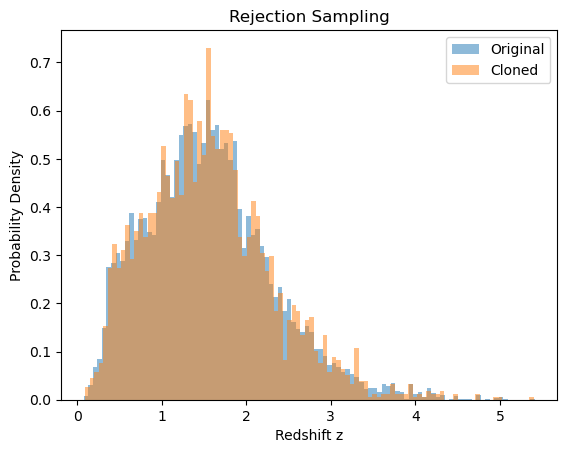

In [ ]:
N = 10000
hist = np.histogram(z, bins=100, density=True)
distr = stats.rv_histogram(hist, density=True)  # Generate a distribution given the data histogram

z_new = np.random.uniform(0, np.max(z), N)
y_new = np.random.uniform(0, np.max(distr.pdf(z)), N)

z_mc = []
y_mc = []

for i in range (N):
    if y_new[i]<=distr.pdf(z_new[i]):
        z_mc.append(z_new[i])
        y_mc.append(y_new[i])

plt.hist (z, 100, density = True, alpha = 0.5, label='Original')
plt.hist (z_mc, 100, density = True, alpha = 0.5, label='Cloned')
plt.title('Rejection Sampling')
plt.xlabel('z')
plt.ylabel('pdf(z)')
plt.legend()

Let's now see the inverse transform:

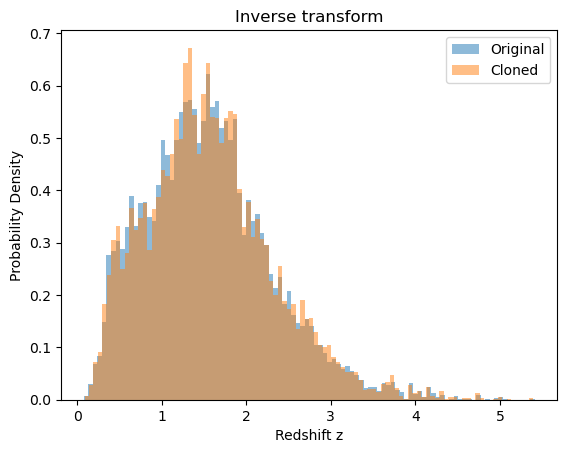

In [ ]:
N = 10000

z_is = []

for i in range(N):
    u = np.random.uniform(0,1)
    inv_samp = distr.ppf(u)
    z_is.append(inv_samp)

plt.hist (z, 100, density=True, alpha=0.5, label='Original')
plt.hist (z_is, 100, density=True, alpha=0.5, label='Cloned')
plt.title('Inverse transform')
plt.xlabel('z')
plt.ylabel('pdf(z)')
plt.legend()

Both distributions appear similar to the observed one!

Lastly, let's compare our distribution of Quasars to the theorethical one and see if they agree:

In [28]:
import astropy
astropy.cosmology.Planck15

FlatLambdaCDM(name="Planck15", H0=67.74 km / (Mpc s), Om0=0.3075, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.0486)

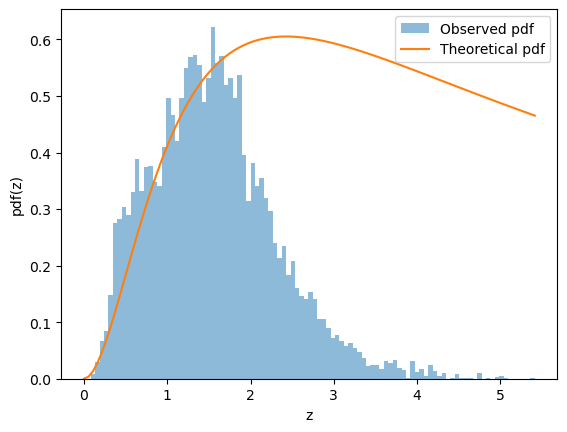

In [32]:
z_grid = np.linspace(0, np.max(z), 100)

pdf = 4.*np.pi*astropy.cosmology.Planck18.differential_comoving_volume(z_grid).value
norm_const = np.trapz(pdf, z_grid)
pdf_norm = pdf/norm_const

plt.hist(z,100, density = True, alpha=0.5, label = 'Observed pdf')
plt.plot(z_grid, 2.6*pdf_norm, label='Theoretical pdf') #Adding a fudge factor to 'match' the 2 distributions
plt.xlabel('z')
plt.ylabel('pdf(z)')
plt.legend()

The two distributions seem to match at low redshift, while for higher values we observe fewer quasars than expected. This could be due to the fact that as z increases, we are observing further away, thus detecting fewer objects.